In [8]:
ls /gpfs/data/gpfs0/timofey.glukhikh/Science_Phan/runs/bitrate_sr_swin

img0017_swin_psnr35_lam0.2_r4_direct/  img0471_swin_psnr35_lam0.8_r4_direct/
img0017_swin_psnr35_lam0.5_r4_direct/  img0471_swin_psnr35_lam1_r4_direct/
img0017_swin_psnr35_lam0.6_r4_direct/  img0492_swin_psnr35_lam0.2_r4_direct/
img0017_swin_psnr35_lam0.8_r4_direct/  img0492_swin_psnr35_lam0.5_r4_direct/
img0017_swin_psnr35_lam1_r4_direct/    img0492_swin_psnr35_lam0.6_r4_direct/
img0268_swin_psnr35_lam0.2_r4_direct/  img0492_swin_psnr35_lam0.8_r4_direct/
img0268_swin_psnr35_lam0.5_r4_direct/  img0492_swin_psnr35_lam1_r4_direct/
img0268_swin_psnr35_lam0.6_r4_direct/  img0672_swin_psnr35_lam0.2_r4_direct/
img0268_swin_psnr35_lam0.8_r4_direct/  img0672_swin_psnr35_lam0.5_r4_direct/
img0268_swin_psnr35_lam1_r4_direct/    img0672_swin_psnr35_lam0.6_r4_direct/
img0323_swin_psnr35_lam0.2_r4_direct/  img0672_swin_psnr35_lam0.8_r4_direct/
img0323_swin_psnr35_lam0.5_r4_direct/  img0672_swin_psnr35_lam1_r4_direct/
img0323_swin_psnr35_lam0.6_r4_direct/  img0682_swin_psnr35_lam0.2_r4_direct/
img03

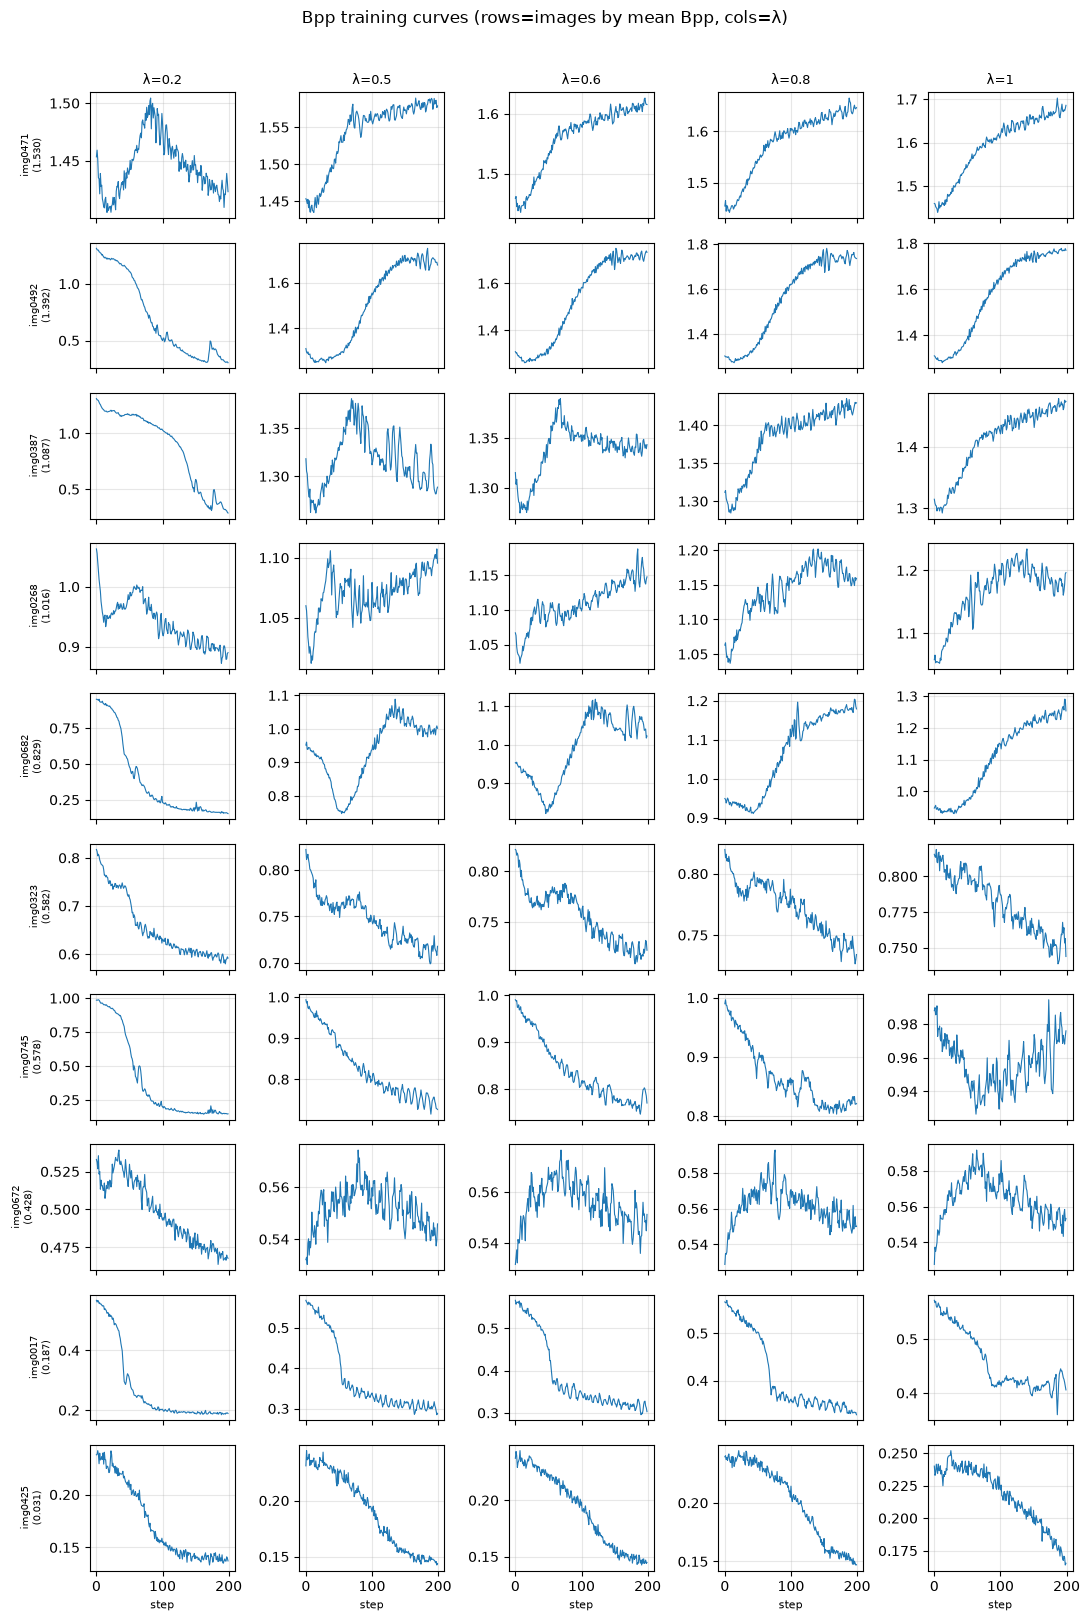

In [25]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/gpfs/data/gpfs0/timofey.glukhikh/Science_Phan/runs/bitrate_sr_swin")
LAMS = ["0.2", "0.5", "0.6", "0.8", "1"]

imgs = list({
    p.name.split("_swin_")[0]
    for p in ROOT.glob("img*_swin_psnr35_lam*_r4_direct")
})

def run_dir(img: str, lam: str) -> Path:
    return ROOT / f"{img}_swin_psnr35_lam{lam}_r4_direct"

def mean_bpp(img: str) -> float:
    vals = []
    for lam in LAMS:
        mf = run_dir(img, lam) / "metrics.json"
        if mf.exists():
            vals.append(json.loads(mf.read_text())["Bpp"])
    return float(np.mean(vals)) if vals else float("inf")

# в цикле:
d = run_dir(img, lam)
cpath = d / "curves.npz"

# низкий bpp сверху; для наоборот добавь reverse=True
imgs = sorted(imgs, key=mean_bpp, reverse=True)

n_r, n_c = len(imgs), len(LAMS)
fig, axes = plt.subplots(n_r, n_c, figsize=(2.2 * n_c, 1.6 * n_r), sharex=True, sharey=False)

if n_r == 1:
    axes = np.array([axes])

for i, img in enumerate(imgs):
    for j, lam in enumerate(LAMS):
        ax = axes[i, j]
        d = run_dir(img, lam) 
        cpath = d / "curves.npz"
        if not cpath.exists():
            ax.set_axis_off()
            continue
        b = np.load(cpath)["bpp_values"]
        ax.plot(b, lw=0.8)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title(f"λ={lam}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{img}\n({mean_bpp(img):.3f})", fontsize=7)
        if i == n_r - 1:
            ax.set_xlabel("step", fontsize=8)

fig.suptitle("Bpp training curves (rows=images by mean Bpp, cols=λ)", y=1.01)
fig.tight_layout()
plt.show()

In [21]:
for lam in ["1", "0.8", "0.6", "0.5", "0.2"]:
    d = ROOT / f"img0268_swin_psnr35_lam{lam}_r4_direct"
    m = json.loads((d / "metrics.json").read_text())
    b = np.load(d / "curves.npz")["bpp_values"]
    print(f"λ={lam}: metric_Bpp={m['Bpp']:.4f}  curve {b[0]:.4f}->{b[-1]:.4f}  min={b.min():.4f}")

λ=1: metric_Bpp=1.1143  curve 1.0577->1.1965  min=1.0520
λ=0.8: metric_Bpp=1.0852  curve 1.0630->1.1593  min=1.0368
λ=0.6: metric_Bpp=1.0812  curve 1.0670->1.1478  min=1.0230
λ=0.5: metric_Bpp=1.0108  curve 1.0600->1.0955  min=1.0119
λ=0.2: metric_Bpp=0.7862  curve 1.0629->0.8902  min=0.8725


In [22]:
1

1